# Exploratory Data Analysis
We will start by loading the dataset and checking for missing values or unnecessary columns.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv('/content/data.csv')

# Examine the first few rows
display(df.head())

# Check for missing values
print("\nMissing values in each column:")
print(df.isnull().sum())

# Summary information
print("\nDataframe Info:")
df.info()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN



Missing values in each column:
id                           0
diagnosis                    0
radius_mean                  0
texture_mean                 0
perimeter_mean               0
area_mean                    0
smoothness_mean              0
compactness_mean             0
concavity_mean               0
concave points_mean          0
symmetry_mean                0
fractal_dimension_mean       0
radius_se                    0
texture_se                   0
perimeter_se                 0
area_se                      0
smoothness_se                0
compactness_se               0
concavity_se                 0
concave points_se            0
symmetry_se                  0
fractal_dimension_se         0
radius_worst                 0
texture_worst                0
perimeter_worst              0
area_worst                   0
smoothness_worst             0
compactness_worst            0
concavity_worst              0
concave points_worst         0
symmetry_worst               0
fractal

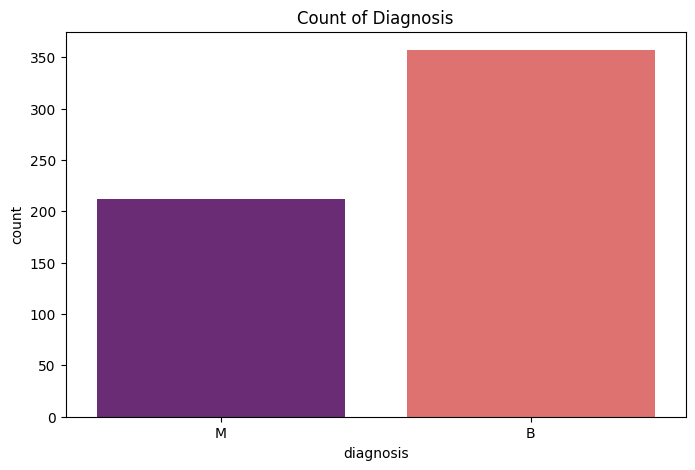

In [3]:
# Drop unnecessary columns (Commonly 'id' or columns with all nulls like 'Unnamed: 32')
# Adjust these column names if your specific data.csv differs
columns_to_drop = [col for col in ['id', 'Unnamed: 32'] if col in df.columns]
df = df.drop(columns=columns_to_drop)

# Create a Countplot to display diagnosis
plt.figure(figsize=(8, 5))
sns.countplot(x='diagnosis', data=df, hue='diagnosis', palette='magma', legend=False)
plt.title('Count of Diagnosis')
plt.show()

# Data Preprocessing
Mapping categorical values to numerical and splitting the data for training and testing.

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Print counts of unique rows in 'diagnosis'
print("Diagnosis counts:")
print(df['diagnosis'].value_counts())

# Map categorical values to numerical (e.g., M=1, B=0)
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})

# Splitting features and target
X = df.drop('diagnosis', axis=1)
y = df['diagnosis']

# Split the data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scaling the data (recommended for KNN and SVM)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Diagnosis counts:
diagnosis
B    357
M    212
Name: count, dtype: int64


# Model Implementation and Evaluation
We will now implement the four models and compare their accuracy.

In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

results = {}

# 1. Logistic Regression
lr = LogisticRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)
results['Logistic Regression'] = accuracy_score(y_test, lr_pred)
print(f"Logistic Regression Accuracy: {results['Logistic Regression']:.4f}")

# 2. K Nearest Neighbours
knn = KNeighborsClassifier()
knn.fit(X_train, y_train)
knn_pred = knn.predict(X_test)
results['KNN'] = accuracy_score(y_test, knn_pred)
print(f"KNN Accuracy: {results['KNN']:.4f}")

# 3. Random Forest
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
results['Random Forest'] = accuracy_score(y_test, rf_pred)
print(f"Random Forest Accuracy: {results['Random Forest']:.4f}")

# 4. SVM
svm = SVC()
svm.fit(X_train, y_train)
svm_pred = svm.predict(X_test)
results['SVM'] = accuracy_score(y_test, svm_pred)
print(f"SVM Accuracy: {results['SVM']:.4f}")

Logistic Regression Accuracy: 0.9737
KNN Accuracy: 0.9474
Random Forest Accuracy: 0.9649
SVM Accuracy: 0.9825


In [6]:
# Determine the best model
best_model = max(results, key=results.get)
print(f"\nThe best model is {best_model} with an accuracy of {results[best_model]:.4f}")


The best model is SVM with an accuracy of 0.9825
